In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input

In [ ]:
# Veri yolu ve parametreleri
train_data_dir = '/content/drive/MyDrive/TomatoDisease/Dataset/train'
test_data_dir = '/content/drive/MyDrive/TomatoDisease/Dataset/test'
img_width, img_height = 224, 224
batch_size = 32
num_classes = 10

In [ ]:
# Veri ön işleme ve artırma
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True)

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 18365 images belonging to 10 classes.
Found 4605 images belonging to 10 classes.


In [ ]:
# ResNet50V2 Modeli

base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Yeni modeli oluşturma
model = tf.keras.models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Modeli derleme
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94668760/94668760 [==============================] - 1s 0us/step


In [ ]:
history = model.fit(train_generator, epochs=10, validation_data=test_generator, use_multiprocessing=True, workers = 64)

Epoch 1/10


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


282/574 [=============>................] - ETA: 3:05:21 - loss: 0.8804 - accuracy: 0.7160

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                5130      
                                                                 
Total params: 24619018 (93.91 MB)
Trainable params: 24573578 (93.74 MB)
Non-trainable params: 45440 (177.50 KB)
__________

In [ ]:
test_steps_per_epoch = np.ceil(test_generator.samples / test_generator.batch_size)

test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps_per_epoch)
print(f'Test Doğruluğu: {test_accuracy * 100:.2f}%')

144/144 [==============================] - 14s 100ms/step - loss: 0.3090 - accuracy: 0.9192
Test Doğruluğu: 91.92%


In [ ]:
predIdx=model.predict(test_generator)
pred=np.argmax(predIdx,axis=1)

144/144 [==============================] - 16s 105ms/step


In [ ]:
print(classification_report(test_generator.classes,pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       425
           1       0.88      0.95      0.91       480
           2       0.98      0.89      0.93       463
           3       0.99      0.79      0.88       470
           4       0.95      0.86      0.90       436
           5       0.93      0.90      0.92       445
           6       0.79      0.97      0.87       457
           7       0.99      0.94      0.97       490
           8       0.81      0.99      0.89       458
           9       0.95      1.00      0.98       481

    accuracy                           0.92      4605
   macro avg       0.93      0.92      0.92      4605
weighted avg       0.93      0.92      0.92      4605



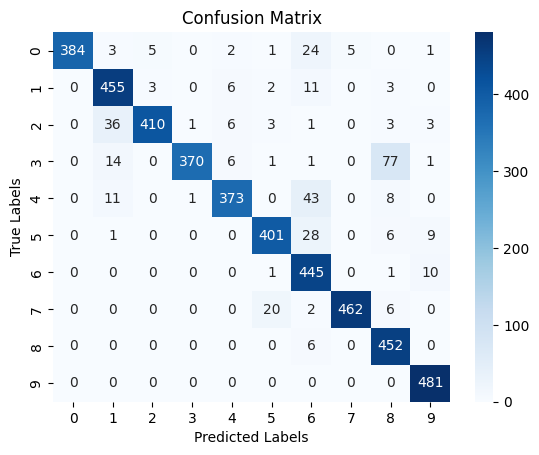

In [ ]:
import seaborn as sns
cm = confusion_matrix(test_generator.classes, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

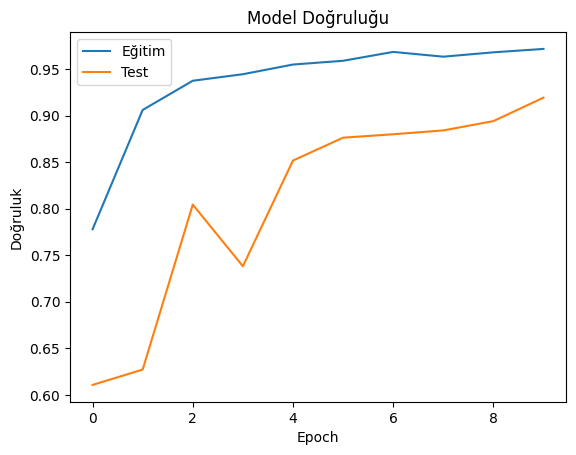

In [ ]:
# Doğruluk oranını çizme
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Doğruluğu')
plt.ylabel('Doğruluk')
plt.xlabel('Epoch')
plt.legend(['Eğitim', 'Test'], loc='upper left')
plt.show()